Dataset Shape: (1000, 44)
Columns: ['mean_spectral_centroid', 'std_spectral_centroid', 'mean_spectral_bandwidth', 'std_spectral_bandwidth', 'mean_spectral_contrast', 'mean_spectral_flatness', 'mean_spectral_rolloff', 'zero_crossing_rate', 'rms_energy', 'mean_pitch', 'min_pitch', 'max_pitch', 'std_pitch', 'spectral_skew', 'spectral_kurtosis', 'energy_entropy', 'log_energy', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'label']

--- First 5 Rows ---
   mean_spectral_centroid  std_spectral_centroid  mean_spectral_bandwidth  \
0             2123.620357             348.106343               892.558526   
1             3852.142919             633.520758      

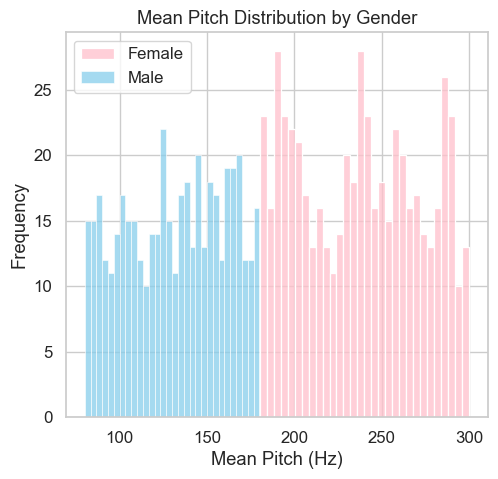

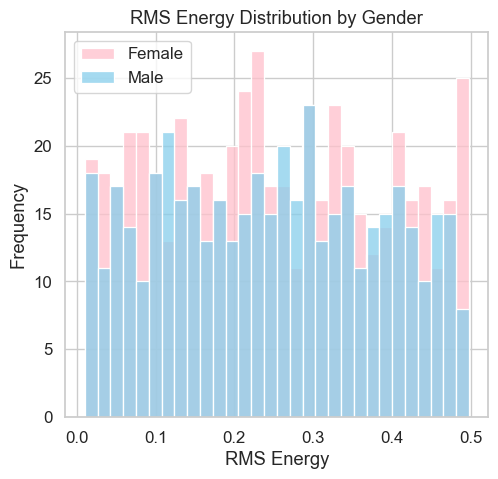


--- Bivariate Analysis ---


C:\Users\ruchi\AppData\Local\Temp\ipykernel_4140\3723186791.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='rms_energy', data=df, palette='Set2')


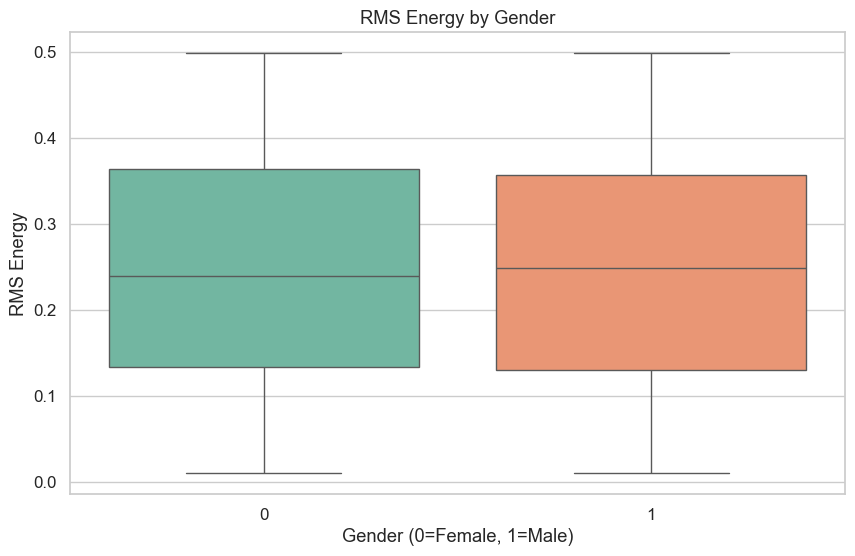

C:\Users\ruchi\AppData\Local\Temp\ipykernel_4140\3723186791.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='mean_pitch', data=df, palette='Set3')


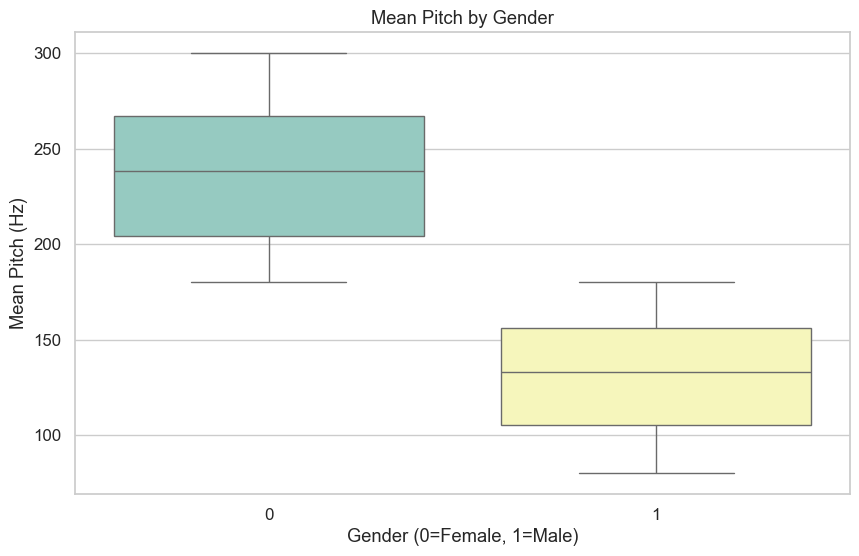


--- Multivariate Analysis ---


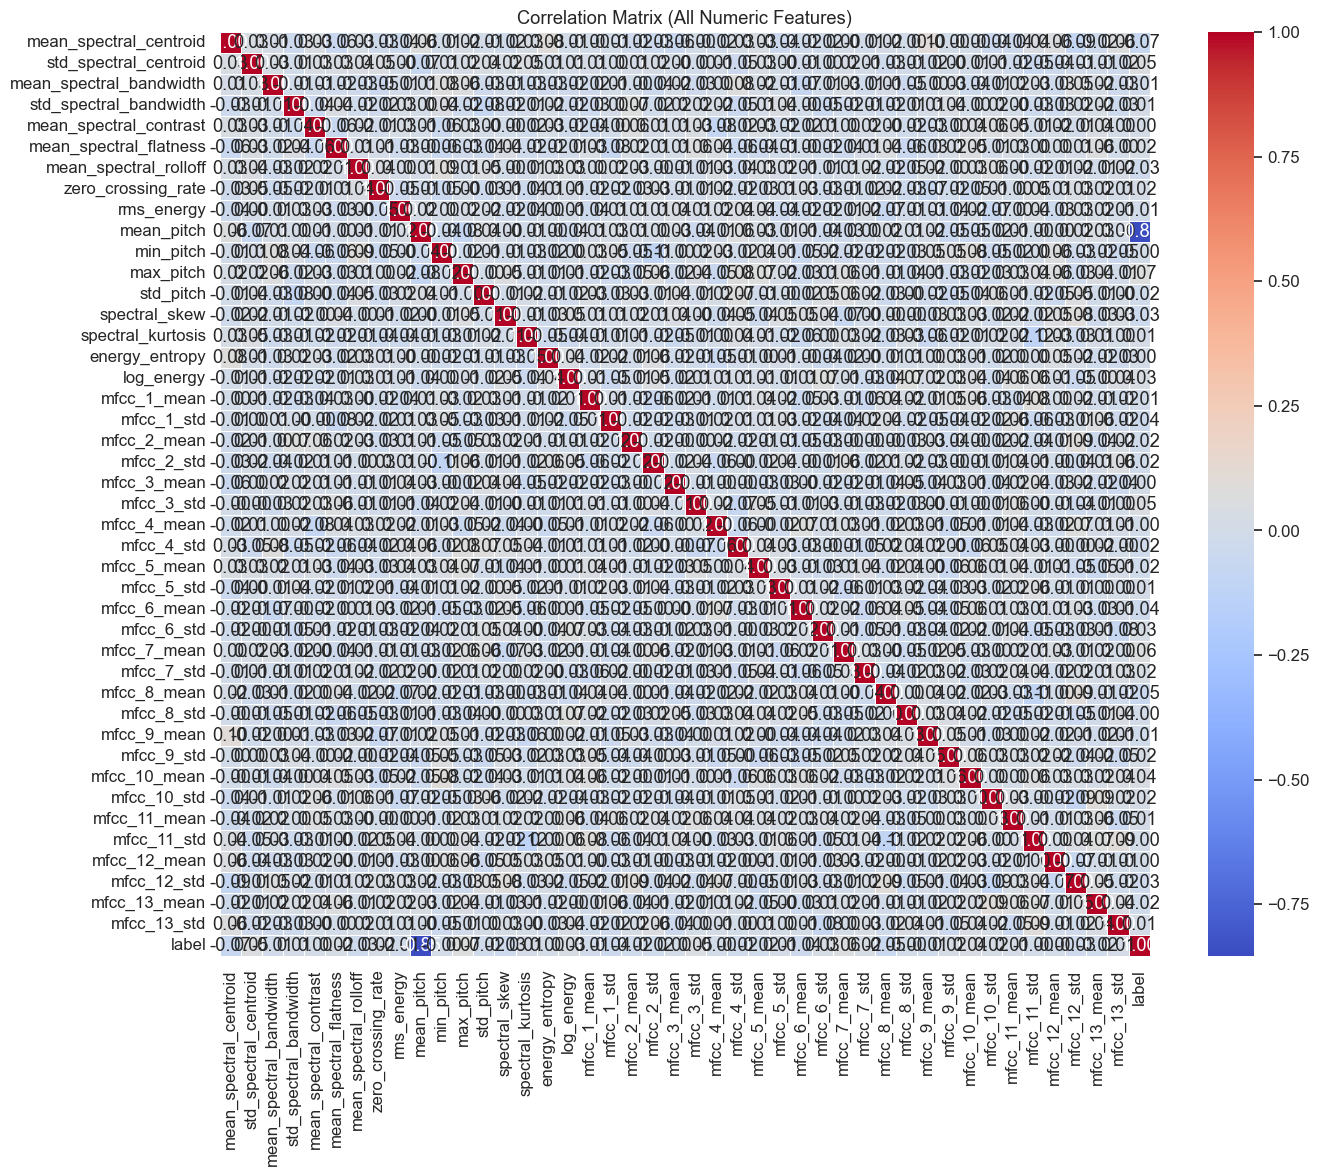


--- Feature Selection Insights ---
Top 10 Features Correlated with Target:
label                     1.000000
mean_pitch                0.854779
max_pitch                 0.066458
mean_spectral_centroid    0.065154
mfcc_7_mean               0.061867
mfcc_8_mean               0.053027
std_spectral_centroid     0.052482
mfcc_3_std                0.046532
mfcc_6_mean               0.042926
mfcc_10_mean              0.042720
Name: label, dtype: float64

--- Key Statistics ---
       mean_spectral_centroid  std_spectral_centroid  mean_spectral_bandwidth  \
count             1000.000000            1000.000000              1000.000000   
mean              2470.769660             605.613844              1253.608589   
std                876.412086             233.751915               436.011293   
min               1013.896069             202.574611               500.017452   
25%               1707.919803             392.859417               892.026466   
50%               2490.422130       

In [1]:
# Step 2: Data Preparation & EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for better visuals
sns.set_theme(style="whitegrid", font_scale=1.1)

# Ensure output directory exists
os.makedirs('../docs/eda_images', exist_ok=True)

# 1. Load Data
# Adjust path if your data is in a different location
data_path = '../data/raw/human_voice_clustering.csv'
df = pd.read_csv(r'C:\Users\ruchi\OneDrive\Desktop\streamlit_app\env\Scripts\voice_data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\n--- First 5 Rows ---")
print(df.head())

# 2. Data Cleaning & Missing Values
print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Impute missing values with median (for numerical features)
if missing_values.sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing values imputed with median.")
else:
    print("No missing values found.")

# 3. Target Check
print("\n--- Target Variable Check ---")
print(f"Target Column: 'label'")
print(f"Unique Values: {df['label'].unique()}")
print(f"Value Counts:\n{df['label'].value_counts()}")

# Ensure label is binary (0/1)
if df['label'].nunique() != 2:
    print("Warning: Label is not binary. Converting to binary...")
    # Example: If labels are 'male'/'female', convert to 1/0
    df['label'] = df['label'].map({'male': 1, 'female': 0})

# 4. Univariate Analysis (Single Variable)
print("\n--- Univariate Analysis ---")

# A. Histograms for mean_pitch (Male vs Female)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[df['label'] == 0]['mean_pitch'], bins=30, color='pink', label='Female')
sns.histplot(df[df['label'] == 1]['mean_pitch'], bins=30, color='skyblue', label='Male')
plt.title('Mean Pitch Distribution by Gender')
plt.xlabel('Mean Pitch (Hz)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('../docs/eda_images/mean_pitch_by_gender.png', dpi=300)
plt.show()

# B. Histograms for rms_energy (Male vs Female)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.histplot(df[df['label'] == 0]['rms_energy'], bins=30, color='pink', label='Female')
sns.histplot(df[df['label'] == 1]['rms_energy'], bins=30, color='skyblue', label='Male')
plt.title('RMS Energy Distribution by Gender')
plt.xlabel('RMS Energy')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('../docs/eda_images/rms_energy_by_gender.png', dpi=300)
plt.show()

# 5. Bivariate Analysis (Two Variables)
print("\n--- Bivariate Analysis ---")

# A. Boxplots for rms_energy by gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='rms_energy', data=df, palette='Set2')
plt.title('RMS Energy by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('RMS Energy')
plt.savefig('../docs/eda_images/rms_energy_boxplot.png', dpi=300)
plt.show()

# B. Boxplots for mean_pitch by gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='mean_pitch', data=df, palette='Set3')
plt.title('Mean Pitch by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Mean Pitch (Hz)')
plt.savefig('../docs/eda_images/mean_pitch_boxplot.png', dpi=300)
plt.show()

# 6. Multivariate Analysis (Correlation)
print("\n--- Multivariate Analysis ---")

# Select numeric columns for correlation (exclude label for now)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(15, 12))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (All Numeric Features)')
plt.savefig('../docs/eda_images/correlation_heatmap.png', dpi=300)
plt.show()

# 7. Feature Selection Insights
print("\n--- Feature Selection Insights ---")
# Identify highly correlated features with target
correlation_with_target = corr_matrix['label'].abs().sort_values(ascending=False)
print("Top 10 Features Correlated with Target:")
print(correlation_with_target.head(10))

# Save feature importance for later use
correlation_with_target.to_csv('../docs/feature_importance.csv')

# 8. Summary Statistics
print("\n--- Key Statistics ---")
print(df.describe())
print("\n--- Gender Distribution ---")
print(df['label'].value_counts(normalize=True))